In [1]:
!pip install catboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [3]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


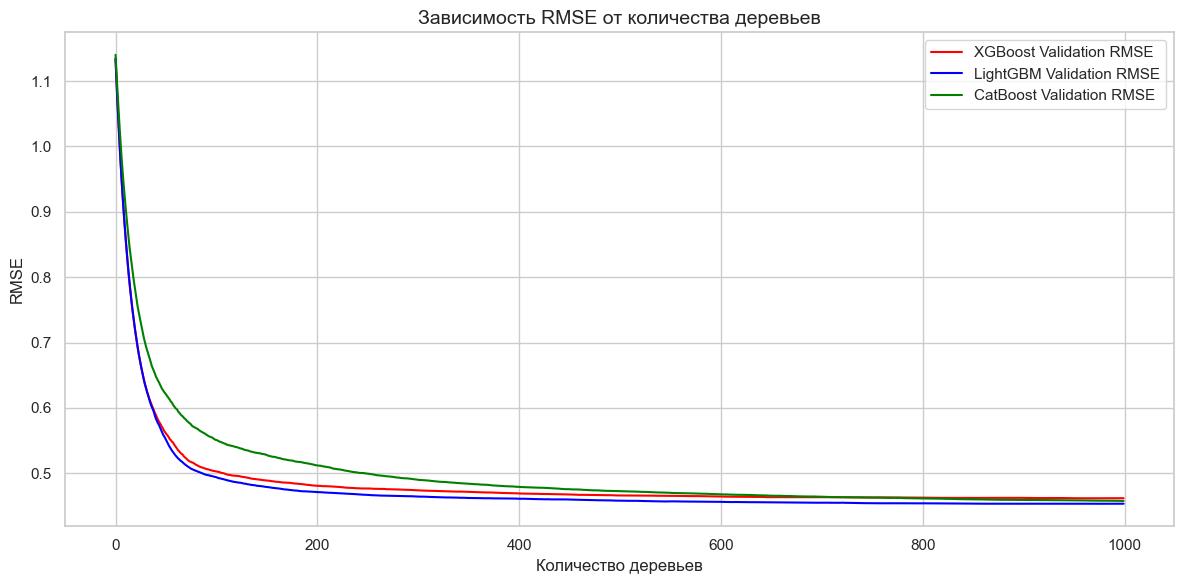

In [4]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
SELECTED_N_ESTIMATORS = 400

### Свой класс: градиентный бустинг с расширенным функционалом, по заданию:
- subsample       : случайная подвыборка объектов для каждого дерева
- colsample_bytree: случайная подвыборка признаков для каждого дерева
- feature_importances_: усреднённая важность признаков по ансамблю
- Target Encoding: нативная поддержка категориальных признаков 

In [6]:
class MyBoost:

    def __init__(self, n=400, lr=0.05, depth=7, seed=42,
                 subsample=1.0, colsample_bytree=1.0) -> None:
     
        self.n = n               # количество деревьев
        self.lr = lr             # шаг градиентного спуска
        self.depth = depth       # максимальная глубина каждого дерева
        self.seed = seed             # стартовое значение для воспроизводимости
        self.subsample = subsample             # доля объектов обучающей выборки (от 0 до 1) задание
        self.colsample_bytree = colsample_bytree  # доля признаков, используемая для обучения аналог метода случайных подпространств

        self.trees = []
        self._col_indices = []   # индексы признаков, использованных каждым деревом
        self._cat_cols = []      # индексы категориальных столбцов
        self._feature_names = None


    # Вспомогательный метод: подготовка X (кодирование + конвертация)

    # Проверяет, является ли столбец категориальным.
    def _is_categorical(self, series):
        return series.dtype.name in ('object', 'category', 'str') \
               or str(series.dtype) == 'string'


        """
        Преобразует входной X в float-массив.
        При fit=True:
          - запоминает имена признаков и категориальные столбцы
          - обучает маппинг категория -> среднее(y) (Target Encoding)
        При fit=False:
          - применяет уже обученный маппинг
          - неизвестные категории заменяются глобальным средним
        """
    def _prepare_X(self, X, y=None, fit: bool = False) -> np.ndarray:
        if isinstance(X, pd.DataFrame):
            if fit:
                self._feature_names = list(X.columns)
                self._cat_cols = [
                    i for i, col in enumerate(X.columns)
                    if self._is_categorical(X[col])
                ]
            # object-массив сохраняет строки без ошибок до кодирования
            X_arr = X.values.copy().astype(object)
        else:
            if fit:
                self._feature_names = [f'f{i}' for i in range(X.shape[1])]
                self._cat_cols = []
            X_arr = np.array(X, dtype=object)

        # Target Encoding для категориальных признаков
        if self._cat_cols:
            if fit:
                self._cat_encoders = {}
                y_arr = np.array(y, dtype=float)
                self._global_mean = float(y_arr.mean())
                for col in self._cat_cols:
                    mapping = {}
                    for val in np.unique(X_arr[:, col]):
                        mapping[val] = float(y_arr[X_arr[:, col] == val].mean())
                    self._cat_encoders[col] = mapping
            # Применяем маппинг
            for col in self._cat_cols:
                X_arr[:, col] = np.array([
                    self._cat_encoders[col].get(v, self._global_mean)
                    for v in X_arr[:, col]
                ])

        return X_arr.astype(float)


    # Обучение
    def fit(self, X, y):
        rng = np.random.RandomState(self.seed)

        X_arr = self._prepare_X(X, y, fit=True)
        y_arr = np.array(y, dtype=float)
        n_features = X_arr.shape[1]

        self.initial_leaf = y_arr.mean()
        predictions = np.full(len(y_arr), self.initial_leaf)
        self.trees = []
        self._col_indices = []

        for _ in range(self.n):
            antigrad = y_arr - predictions
            n_samples = X_arr.shape[0]

            # subsample: случайная подвыборка объектов 
            if self.subsample < 1.0:
                n_sub = max(1, int(n_samples * self.subsample))
                row_idx = rng.choice(n_samples, size=n_sub, replace=False)
            else:
                row_idx = np.arange(n_samples)

            # colsample_bytree: случайная подвыборка признаков 
            if self.colsample_bytree < 1.0:
                n_cols = max(1, int(n_features * self.colsample_bytree))
                col_idx = np.sort(rng.choice(n_features, size=n_cols, replace=False))
            else:
                col_idx = np.arange(n_features)

            self._col_indices.append(col_idx)

            tree = DecisionTreeRegressor(
                max_depth=self.depth,
                random_state=self.seed,
                criterion='friedman_mse'
            )
            tree.fit(X_arr[np.ix_(row_idx, col_idx)], antigrad[row_idx])
            self.trees.append(tree)

            # Обновляем предсказания на всей выборке (не только на подвыборке)
            predictions += tree.predict(X_arr[:, col_idx]) * self.lr



    # Предсказание
    def predict(self, samples):
        X_arr = self._prepare_X(samples)
        predictions = np.full(X_arr.shape[0], self.initial_leaf)
        for i, tree in enumerate(self.trees):
            col_idx = self._col_indices[i]
            predictions += self.lr * tree.predict(X_arr[:, col_idx])
        return predictions



    # Важность признаков
    """
    Возвращает нормализованный массив важностей признаков.
    Вычисляется как взвешенное (по lr) среднее feature_importances_
    всех деревьев в ансамбле. Признаки, не попавшие в подвыборку
    конкретного дерева, получают нулевой вклад от него.
    """
    @property
    def feature_importances_(self):
  
        if not self.trees:
            raise RuntimeError('Модель не обучена. Сначала вызовите fit().')

        n_features = len(self._feature_names)
        importances = np.zeros(n_features)

        for tree, col_idx in zip(self.trees, self._col_indices):
            for local_i, global_i in enumerate(col_idx):
                importances[global_i] += self.lr * tree.feature_importances_[local_i]

        total = importances.sum()
        if total > 0:
            importances /= total
        return importances


Демонстрация MyBoost

MyBoost  MAE=0.2973  RMSE=0.4535  R²=0.8431


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28304\2355838556.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x="Важность", y="Признак", palette="viridis")


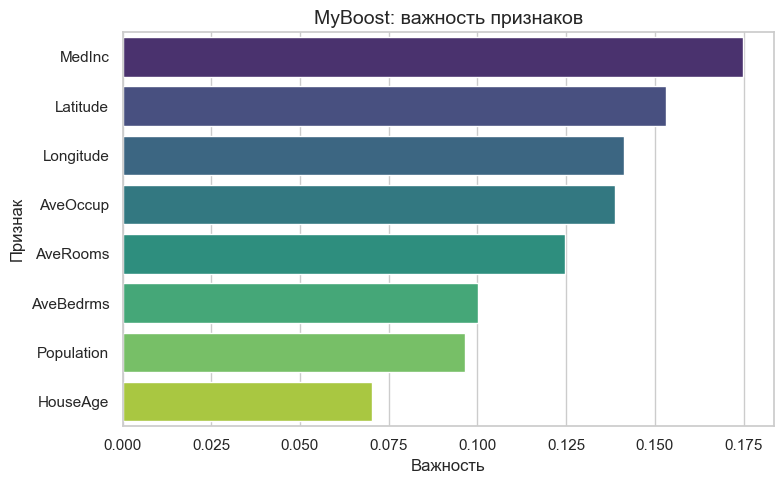

,Признак,Важность
0,MedInc,0.174850
1,Latitude,0.153042
2,Longitude,0.141219
3,AveOccup,0.138758
4,AveRooms,0.124809
5,AveBedrms,0.100279
6,Population,0.096625
7,HouseAge,0.070419


In [7]:
# Обучаем MyBoost с subsampling и colsampling
my_model = MyBoost(
    n=SELECTED_N_ESTIMATORS,
    lr=0.05,
    depth=7,
    subsample=0.8,          # используем 80% объектов для каждого дерева
    colsample_bytree=0.8    # используем 80% признаков для каждого дерева
)
my_model.fit(X_train, y_train)
my_preds = my_model.predict(X_test)

my_rmse = np.sqrt(mean_squared_error(y_test, my_preds))
my_mae  = mean_absolute_error(y_test, my_preds)
my_r2   = r2_score(y_test, my_preds)

print(f"MyBoost  MAE={my_mae:.4f}  RMSE={my_rmse:.4f}  R²={my_r2:.4f}")

# важность по признакам
fi = my_model.feature_importances_
fi_df = pd.DataFrame({
    "Признак": my_model._feature_names,
    "Важность": fi
}).sort_values("Важность", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=fi_df, x="Важность", y="Признак", palette="viridis")
plt.title("MyBoost: важность признаков", fontsize=14)
plt.tight_layout()
plt.show()
display(fi_df.reset_index(drop=True))


In [8]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

def simple_grid_search(model_name, param_grid):
    print(f"Запуск Grid Search для {model_name}")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        else:
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)

Запуск Grid Search для XGBoost
Лучший Validation RMSE: 0.4619
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'subsample': 0.8}

Запуск Grid Search для LightGBM
Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}

Запуск Grid Search для CatBoost
Лучший Validation RMSE: 0.4564
Лучшие параметры: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}



,Модель,Время обучения (с),MAE,RMSE,R2 Score
0,XGBoost,1.244,0.2889,0.4455,0.8485
1,LightGBM,0.434,0.2862,0.4379,0.8537
2,CatBoost,1.603,0.2967,0.4493,0.8460
3,MyBoost,26.599,0.2917,0.4457,0.8484


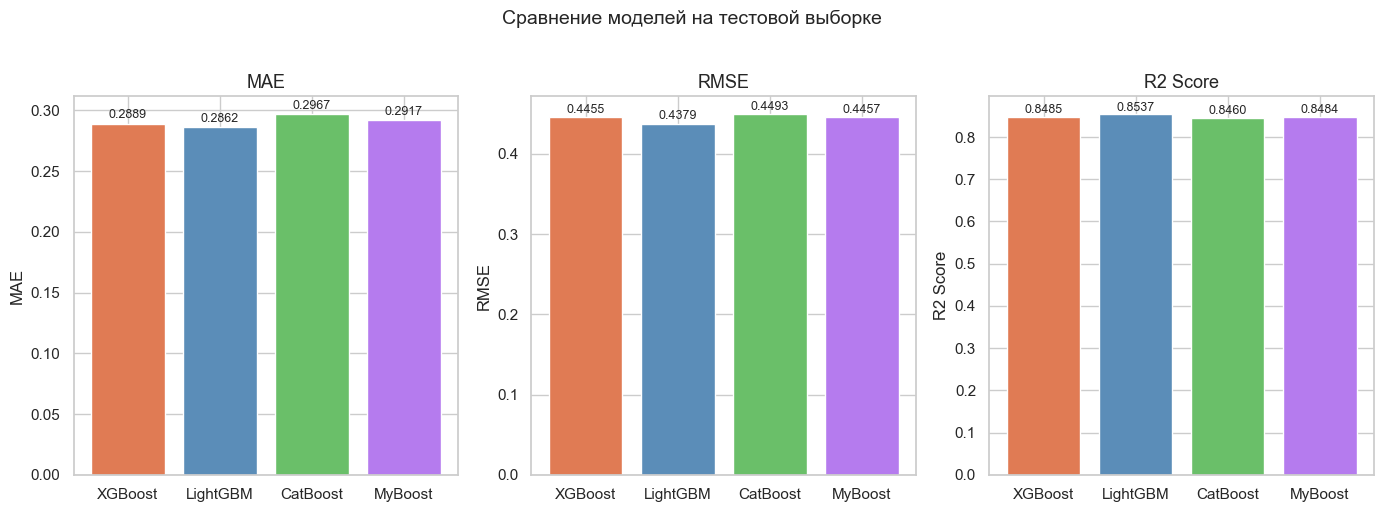

In [ ]:
results = []

for name in ['XGBoost', 'LightGBM', 'CatBoost', 'MyBoost']:
    params = best_params_dict.get(name)

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **params)
    elif name == 'MyBoost':
        model = MyBoost(n=SELECTED_N_ESTIMATORS, lr=0.05, depth=7, subsample=0.8, colsample_bytree=0.8)
    else:
        model = cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0, **params)

    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения (с)": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["MAE", "RMSE", "R2 Score"]
colors = ["#e07b54", "#5b8db8", "#6abf69", "#b57bee"]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(df_results["Модель"], df_results[metric], color=colors)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.4f}", ha='center', va='bottom', fontsize=9)

plt.suptitle("Сравнение моделей на тестовой выборке", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Сравнительная оценка MyBoost

**MyBoost** показал результат, сопоставимый с библиотечными реализациями:

- **MAE** = 0.2917  
- **RMSE** = 0.4457  
- **R²** = 0.8484  

Это практически на уровне **XGBoost** (RMSE = 0.4455), что подтверждает корректность реализации базового алгоритма градиентного бустинга.

### Главный недостаток — скорость

- Время работы **MyBoost**: 26.6 секунд  
- Время работы библиотечных решений: 0.4–1.6 секунд, поскольку в MyBoost отсутствуют оптимизации.

### Лучший результат по совокупности критериев

**LightGBM**  
- Качество: RMSE = 0.4379, R² = 0.8537  
- Скорость: **0.43 секунды** (самый быстрый)

Оптимальный выбор для данной задачи.